# Geodesic distance paths rendering

In [1]:
import os
import numpy as np
import nibabel as nib
import vtk
from vtk.util import numpy_support
from pygeodesic import geodesic
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres

surf_dir="/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC019/ses-03/surf"
fname=f"{surf_dir}/sub-PNC019_ses-03_hemi-L_space-nativepro_surf-fsnative_label-pial.surf.gii"

## Load surface

In [2]:
# Load surface
gii = nib.load(fname)

coords = gii.darrays[0].data
faces = gii.darrays[1].data

n_vertices = coords.shape[0]

print(f"Number of vertices: {n_vertices}")

Number of vertices: 114876


## Chose a reference vertex

In [29]:
# B) Choose reference vertex and compute geodesic distances
ref_vertex = 13048
#ref_vertex = 4458

geo = geodesic.PyGeodesicAlgorithmExact(coords, faces)
distances, _ = geo.geodesicDistances([ref_vertex], None)
distances = np.array(distances)

## Get representative vertices geodesic paths)

In [30]:
# D) Find representative vertices (10–100%)

max_d = distances.max()

rep_vertices = []

for p in range(10, 101, 5):

    target = (p / 100) * max_d
    idx = np.argmin(np.abs(distances - target))
    rep_vertices.append(idx)

print("Representative vertices:", rep_vertices)

Representative vertices: [np.int64(27680), np.int64(99365), np.int64(29773), np.int64(25926), np.int64(112723), np.int64(1087), np.int64(56418), np.int64(59109), np.int64(43970), np.int64(6366), np.int64(78496), np.int64(78700), np.int64(95091), np.int64(64073), np.int64(105208), np.int64(78524), np.int64(100310), np.int64(88500), np.int64(92814)]


In [327]:
rep_vertices=[34660, 44900, 22470, 98643, 11229, 54104, 76105, 48934, 91172, 87708,  55170, 76138, 36852, 78299, 96815]
#46035,

## Create `VTK` surface

In [328]:
# Create VTK surface
points = vtk.vtkPoints()
points.SetData(numpy_support.numpy_to_vtk(coords))

triangles = vtk.vtkCellArray()

for f in faces:
    tri = vtk.vtkTriangle()
    tri.GetPointIds().SetId(0, f[0])
    tri.GetPointIds().SetId(1, f[1])
    tri.GetPointIds().SetId(2, f[2])
    triangles.InsertNextCell(tri)

polydata = vtk.vtkPolyData()
polydata.SetPoints(points)
polydata.SetPolys(triangles)

## Smoothing the surface

In [329]:
# Smooth the surface
smooth = vtk.vtkSmoothPolyDataFilter()
smooth.SetInputData(polydata)
smooth.SetNumberOfIterations(25)      # adjust for smoothness
smooth.SetRelaxationFactor(0.1)       # small relaxation for realistic shape
smooth.FeatureEdgeSmoothingOff()
smooth.BoundarySmoothingOn()
smooth.Update()

polydata = smooth.GetOutput()

## Surface color

In [330]:
map_lh = nib.load("/host/verges/tank/data/youngeun/myjupyter/array/10PNC_hemi-L_space-fsnative_func_average.func.gii").darrays[0].data
map_rh = nib.load("/host/verges/tank/data/youngeun/myjupyter/array/10PNC_hemi-R_space-fsnative_func_average.func.gii").darrays[0].data
func_map = mask_5k = np.concatenate((map_lh, map_rh), axis=0)

In [331]:
fs_lh = read_surface(f"{surf_dir}/sub-PNC019_ses-03_hemi-L_space-nativepro_surf-fsnative_label-pial.surf.gii", itype='gii')
fs_rh = read_surface(f"{surf_dir}/sub-PNC019_ses-03_hemi-R_space-nativepro_surf-fsnative_label-pial.surf.gii", itype='gii')

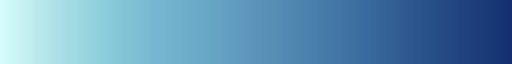

In [332]:
import colormaps as clrmps
import matplotlib.cm as cm
clrmps.blue_8_5g2

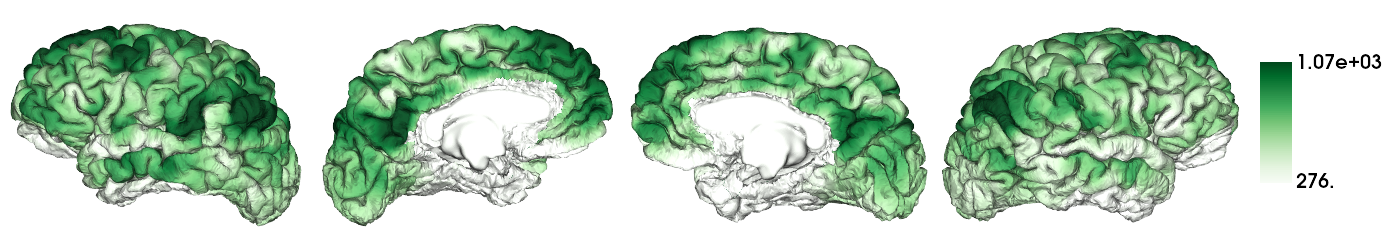

In [333]:
# Calculate an optima range of color for visualization
#crange=(np.quantile(func_map[mask_5k != False], 0.075), np.func_map(fc_ctx[mask_5k != False], 0.98))
# plot the column mean of the mean connectome surface
plot_hemispheres(fs_lh, fs_rh, func_map, cmap='Greens', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True, color_range = (276, 1070),
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

In [345]:
# C) Color surface using modified colormap

# normalize distances
#norm = (distances - distances.min()) / (distances.max() - distances.min())
#norm = (func_map - func_map.min()) / (func_map.max() - func_map.min())
vmin = 276
vmax = 1000
norm = (func_map - vmin) / (vmax - vmin)
norm = np.clip(norm, 0, 1)

# define gradient stops
stops = np.array([0.0, 0.33, 0.66, 1.0])
colors_hex = [
    [1, 1, 1],       # light gray
    [0.8, 0.8, 0.8],       # light gray
    #[0.573, 0.671, 0.745], # 92abbe
    [0.475, 0.576, 0.659], # 7993a8
    [0.173, 0.278, 0.459]  # 2c4775
]

colors = []

for t in norm:
    # find which segment t belongs to
    for i in range(len(stops)-1):
        if stops[i] <= t <= stops[i+1]:
            f = (t - stops[i]) / (stops[i+1]-stops[i])
            r = colors_hex[i][0]*(1-f) + colors_hex[i+1][0]*f
            g = colors_hex[i][1]*(1-f) + colors_hex[i+1][1]*f
            b = colors_hex[i][2]*(1-f) + colors_hex[i+1][2]*f
            colors.append([r,g,b])
            break

cmap = cm.get_cmap("Blues")
colors = cmap(norm)[:, :3]
#colors = np.array(colors)

# Convert to VTK
vtk_colors = numpy_support.numpy_to_vtk(colors)
vtk_colors.SetNumberOfComponents(3)
vtk_colors.SetName("colors")

# Apply to surface
polydata.GetPointData().SetScalars(vtk_colors)

mapper = vtk.vtkPolyDataMapper()
mapper.SetInputData(polydata)
mapper.SetColorModeToDirectScalars()

actor = vtk.vtkActor()
actor.SetMapper(mapper)

# Optional: surface transparency
actor.GetProperty().SetOpacity(1.0)

/tmp/ipykernel_747011/54799110.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")


## Geodesic paths

In [346]:
# E) Compute geodesic paths

values = func_map

# reference vertex color / value
ref_color = colors[ref_vertex]
ref_value = values[ref_vertex]
print(ref_value)

path_actors = []
endpoint_actors = []

for v in rep_vertices:

    # ---------------------------
    # geodesic path
    # ---------------------------
    dist, path = geo.geodesicDistance(ref_vertex, v)
    path = np.array(path)

    pts = vtk.vtkPoints()
    pts.SetData(numpy_support.numpy_to_vtk(path))

    lines = vtk.vtkCellArray()

    polyline = vtk.vtkPolyLine()
    polyline.GetPointIds().SetNumberOfIds(len(path))

    for i in range(len(path)):
        polyline.GetPointIds().SetId(i, i)

    lines.InsertNextCell(polyline)

    path_poly = vtk.vtkPolyData()
    path_poly.SetPoints(pts)
    path_poly.SetLines(lines)

    # tube filter (smooth line)
    tube = vtk.vtkTubeFilter()
    tube.SetInputData(path_poly)
    tube.SetRadius(1.2)
    tube.SetNumberOfSides(20)
    tube.Update()

    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(tube.GetOutputPort())

    actor_path = vtk.vtkActor()
    actor_path.SetMapper(mapper)
    actor_path.GetProperty().SetColor(1.0, 0.83, 0.16)

    path_actors.append(actor_path)

    # ---------------------------
    # endpoint sphere
    # ---------------------------
    vertex_color = colors[v]
    vertex_value = values[v]

    # map difference → sphere size
    value_diff = abs(vertex_value - ref_value)
    radius = 7 - 0.01 * value_diff
    radius = max(radius, 3)
    radius = min(radius, 6)
    print(abs(radius))

    end_sphere = vtk.vtkSphereSource()
    end_sphere.SetCenter(coords[v])
    end_sphere.SetRadius(radius)

    end_mapper = vtk.vtkPolyDataMapper()
    end_mapper.SetInputConnection(end_sphere.GetOutputPort())

    end_actor = vtk.vtkActor()
    end_actor.SetMapper(end_mapper)

    # sphere color = map color
    end_actor.GetProperty().SetColor(
        float(vertex_color[0]),
        float(vertex_color[1]),
        float(vertex_color[2])
    )

    endpoint_actors.append(end_actor)

1197.3872
3
5.4405336
3.5329268
3
3
3
3
4.8222656
3
3
3
5.7763147
3
3
3


## Reference vertex sphere properts

In [347]:
# Reference vertex sphere

sphere = vtk.vtkSphereSource()
sphere.SetCenter(coords[ref_vertex])
sphere.SetRadius(6)

sphere_mapper = vtk.vtkPolyDataMapper()
sphere_mapper.SetInputConnection(sphere.GetOutputPort())

sphere_actor = vtk.vtkActor()
sphere_actor.SetMapper(sphere_mapper)

sphere_actor.GetProperty().SetColor(1.0,0.83,0.16)
#ref_color = colors[ref_vertex]
#sphere_actor.GetProperty().SetColor(ref_color)

## Add a dot to each vertex

In [348]:
# Create vtkPoints from your surface
points = polydata.GetPoints()  # or polydata if no smoothing

# Create a vtkPolyData to hold the points
points_polydata = vtk.vtkPolyData()
points_polydata.SetPoints(points)

# Create a small sphere as the glyph source
sphere_source = vtk.vtkSphereSource()
sphere_source.SetRadius(0.2)   # small dot size, adjust as needed
sphere_source.SetThetaResolution(8)
sphere_source.SetPhiResolution(8)

# Use vtkGlyph3D to place a sphere at each vertex
glyph = vtk.vtkGlyph3D()
glyph.SetSourceConnection(sphere_source.GetOutputPort())
glyph.SetInputData(points_polydata)
glyph.ScalingOff()        # keep same size for all spheres
glyph.Update()

# Create a mapper and actor for the dots
glyph_mapper = vtk.vtkPolyDataMapper()
glyph_mapper.SetInputConnection(glyph.GetOutputPort())

glyph_actor = vtk.vtkActor()
glyph_actor.SetMapper(glyph_mapper)
glyph_actor.GetProperty().SetColor(0.3, 0.3, 0.3)  # black dots

## Render VTK image

In [349]:
# Render VTK
renderer = vtk.vtkRenderer()
renderer.AddActor(actor)          # surface
renderer.AddActor(sphere_actor)   # reference vertex
renderer.AddActor(glyph_actor)    # vertex points

for ea in endpoint_actors:        # endpoint spheres
    renderer.AddActor(ea)

for pa in path_actors:            # geodesic tubes
    renderer.AddActor(pa)

renderer.SetBackground(1,1,1)

renderer.ResetCameraClippingRange()

window = vtk.vtkRenderWindow()
window.AddRenderer(renderer)
window.SetSize(900,900)

interactor = vtk.vtkRenderWindowInteractor()
interactor.SetRenderWindow(window)

window.Render()
interactor.Start()

In [350]:
# render 먼저
window.Render()

# screenshot capture
window_to_image = vtk.vtkWindowToImageFilter()
window_to_image.SetInput(window)
window_to_image.Update()

# save as PNG
writer = vtk.vtkPNGWriter()
writer.SetFileName("brain_render2.png")
writer.SetInputConnection(window_to_image.GetOutputPort())
writer.Write()

# interactive window
interactor.Start()